# 3D implementation
After the previously defined _simple_ integral evaluation schemes, it is possible to apply them to 3D cartesian Gaussians. Considering that any 3D primitive cartesian gaussian can be separated in the components:

$$
G_{ijk} = x_A^iy_A^jz_A^k \exp (-ar^2) = G_i(x, a, A_x)G_j(y, a, A_y)G_k(z, a, A_z)
$$

Where:

$$
G_i(x, a, A_x) =  x_A^i \exp (-ax_A^2)
$$

Then all the operations such as differenciation and integration can be performed in each dimension and the result is the product. Considering the normalization:

$$
G_i^{norm}(x, a, A_x) =  \frac{1}{\sqrt{N_{A,i}}}x_A^i \exp (-ax_A^2)
$$

And the 3D normalized primitive:

$$
G_{ijk} = \frac{1}{\sqrt{N_{A,i}N_{A,j}N_{A,k}}} G_i(x, a, A_x)G_j(y, a, A_y)G_k(z, a, A_z)
$$

## Overlap integrals
The Overlap integrals between two primitive Cartesian Gaussians is:

$$
S_{ab} = S_{ij}S_{kl}S_{mn}
$$

Where each component can be calculated via Obara-Saika recursion. Normalization in 3D requires that $S_{ab} = 1$. Considering the definition of the overlap integral, the simplest way to normalize is to normalize each component. This is the approach that was taken in this case. However, it must be noted that there might be other normalization schemes.

The normalized overlap between two unnormalized primitive cartesian gaussians can be defined as:

$$
S_{ab}^{norm} = \frac{1}{\sqrt{S_{ab}}}  \frac{1}{\sqrt{S_{ab}}}  S_{ij}S_{kl}S_{mn}
$$

We will use the previously defined Obara-Saika functions

In [1]:
import numpy as np

# Angular moment
With it we can now define the 3D functions for overlap and to calculate normalization constants. Howeverl we have to somehow introduce angular moment selection rules, so that in the future matrix elements that are $0$ are not calculated.

Considering this, we will define a Primitive type, which has the following definition:

In [2]:
from py_mods.src.integrals.primitive import Primitive

And we can manually prepare the projections of each angular momentum in Cartesian coodinates:

With this we consider the overlap functions:

And do it in an ever more clear way using a dataclass and refactoring the functions:

In [3]:
from py_mods.src.integrals.uncontracted import S_3D

And we build the normalization constant from the overlap

In [4]:
from py_mods.src.integrals.uncontracted import N_const

Lets see an example for the same angular moment:

In [5]:
basis_1 = Primitive(np.array([0,0,0]), 0.5, 0, 1)
basis_2 = Primitive(np.array([0,0,0]), 0.5, 0, 1)

basis_1.normalization_constant = N_const(basis_1)
basis_1.normalization_constant**2 * S_3D(basis_1, np.array([0,0,0]), basis_1, np.array([0,0,0]))
a = basis_1.normalization_constant**2 * S_3D(basis_1, np.array([0,0,0]), basis_1, np.array([1,0,0]))
print(f'a = {a:.2f}')

a = 0.00


And with a different angular moment, the overlap should be 0:

In [6]:
basis_1 = Primitive(np.array([0,0,0]), 0.5, 0, 1)
basis_2 = Primitive(np.array([0,0,0]), 0.5, 1, 1)

basis_1.normalization_constant = N_const(basis_1)
a = basis_1.normalization_constant**2 * S_3D(basis_1, np.array([0,0,0]), basis_1, np.array([1,0,0]))
b = basis_1.normalization_constant**2 * S_3D(basis_1, np.array([0,0,0]), basis_1, np.array([0,1,0]))
c = basis_1.normalization_constant**2 * S_3D(basis_1, np.array([0,0,0]), basis_1, np.array([0,0,1]))

print(f'a = {a:.2f}, b = {b:.2f}, c = {c:.2f}')

a = 0.00, b = 0.00, c = 0.00


And now same angular momentum with different projections

In [7]:
basis_1 = Primitive(np.array([0,0,0]), 0.5, 1, 1)
basis_2 = Primitive(np.array([0,0,0]), 0.5, 1, 1)

basis_1.normalization_constant = N_const(basis_1)
a = basis_1.normalization_constant**2 * S_3D(basis_1, np.array([1,0,0]), basis_1, np.array([1,0,0]))
b = basis_1.normalization_constant**2 * S_3D(basis_1, np.array([1,0,0]), basis_1, np.array([0,1,0]))
c = basis_1.normalization_constant**2 * S_3D(basis_1, np.array([1,0,0]), basis_1, np.array([0,0,1]))

print(f'a = {a:.2f}, b = {b:.2f}, c = {c:.2f}')

a = 1.00, b = 0.00, c = 0.00


## Kinetic energy integrals
In the same way as overlap, the kinetic energy integral between two Gaussians is:

$$
T_{ab} = T_{ij} S_{kl} S_{mn} + S_{ij} T_{kl} S_{mn} + S_{ij} S_{kl} T_{mn}
$$

We use Obara-Saika for one dimension as before:

And for 3 dimensions we use the previous formula:

In [8]:
from py_mods.src.integrals.uncontracted import T_3D

The kinetic energy of two $l=1$ basis functions if they share projection components:

In [9]:
T_3D(basis_1, np.array([1,0,0]), basis_2, np.array([1,0,0]))

np.float64(3.4802049980198166)

And if they dont

In [10]:
T_3D(basis_1, np.array([1,0,0]), basis_2, np.array([0,1,0]))

np.float64(0.0)

# Contracted Basis sets
It is now time to test all the previous and see if the implementation was correct. To do so we have an example of a STO-3G calculation, in which for the $H$ atom presents the following:
```
#----------------------------------------------------------------------
# Basis Set Exchange
# Version 0.11
# https://www.basissetexchange.org
#----------------------------------------------------------------------
#   Basis set: STO-3G
# Description: STO-3G Minimal Basis (3 functions/AO)
#        Role: orbital
#     Version: 1  (Data from Gaussian09)
#----------------------------------------------------------------------


BASIS "ao basis" SPHERICAL PRINT
#BASIS SET: (3s) -> [1s]
H    S
      0.3425250914E+01       0.1543289673E+00
      0.6239137298E+00       0.5353281423E+00
      0.1688554040E+00       0.4446345422E+00
END

```
That is:

$$
\alpha_i = [3.42525091, 0.62391373, 0.16885540]
$$
$$
d_i=      [0.15432897, 0.53532814, 0.44463454]
$$

A contracted basis is defined as the linear combination:

$$
\mathrm{STO_{3G}}(x) = \sum_i^3 c_i · e ^{-\alpha_i(r-R_a)^2}
$$

Where $c_i$ is the product of the contraction coefficients and the normalization constant (in 3D):
$$
c_i = d_i · N_\mu
$$

In [11]:
# STO-3G data for H 1s
import numpy as np
from py_mods.src.integrals.primitive import Primitive
from py_mods.src.integrals.uncontracted import N_const
from py_mods.src.integrals.contracted import ST_contracted

alphas = [3.42525091, 0.62391373, 0.16885540]
d =      [0.15432897, 0.53532814, 0.44463454]


basis_1 = Primitive(np.array([0., 0., 0.]), 3.42525091, 0, 1)
basis_2 = Primitive(np.array([0., 0., 0.]), 0.62391373, 0, 1)
basis_3 = Primitive(np.array([0., 0., 0.]), 0.16885540, 0, 1)
basis_4 = Primitive(np.array([1.4, 0., 0.]), 3.42525091, 0, 1)
basis_5 = Primitive(np.array([1.4, 0., 0.]), 0.62391373, 0, 1)
basis_6 = Primitive(np.array([1.4, 0., 0.]), 0.16885540, 0, 1)

sto_3g_1s_h1 = [basis_1, basis_2, basis_3]
sto_3g_1s_h2 = [basis_4, basis_5, basis_6]

normalization_constants = np.array([N_const(basis) for basis in sto_3g_1s_h1])

print(normalization_constants)

# Expansion coefficients
c_mu = [d[i] * normalization_constants[i] for i in range(3)]
c_nu = [d[i] * normalization_constants[i] for i in range(3)]

[1.79444183 0.50032649 0.18773546]


In [12]:
from py_mods.src.integrals.basis_set import Contracted
h2_contracted_1 = Contracted(np.array([0,0,0]), alphas, d, 0)
h2_contracted_2 = Contracted(np.array([1.4,0,0]), alphas, d, 0)
h2_basis = [h2_contracted_1, h2_contracted_2]

In [13]:
h2_contracted_1.c_coeff

array([[0.27693436, 0.26783885, 0.08347367]])

Where we can build all uncontracted matrix elements with just the primitives:

In the case of a property, since there are two contracted basis, the matrix elements of the contracted basis in terms of the uncontracted matrix elements would be:

$$
S_{\mu\nu} = \sum_p^{p_{max}} \sum_q^{q_{max}} c^*_{p \mu} c_{q \nu} S_{pq}
$$

Where $c^*_{p \mu}$ refers to the contraction coefficients of basis $\mu$ and $c^*_{q \nu}$ to the ones of basis $\nu$ (where summation might not have the same dimension limit in both cases). Now we will try to get the matrix elements for two STO-3G basis separated 1.4 a.u:

$$
\mathbf{S}_{\mu\nu} =
    \begin{pmatrix}
        1.0    & 0.6593\\
        0.6593 & 1.0
    \end{pmatrix}
$$
$$
\mathbf{T}_{\mu\nu} =
    \begin{pmatrix}
        0.7600    & 0.2365\\
        0.2365 & 0.7600
    \end{pmatrix}
$$

In [14]:
S_sto_3g, T_sto_3g = ST_contracted(h2_basis)
S_sto_3g

array([[0.99999999, 0.6593182 ],
       [0.6593182 , 0.99999999]])

In [15]:
T_sto_3g

array([[0.76003188, 0.23645465],
       [0.23645465, 0.76003188]])

In [16]:
S_sto_3g, T_sto_3g = ST_contracted([h2_contracted_1, h2_contracted_2])
S_sto_3g

array([[0.99999999, 0.6593182 ],
       [0.6593182 , 0.99999999]])

# 3D implementation of coulomb potential and ERIS

In the following cell we are going to copy all we need to use the McMurchie-Davidson scheme implemented previously and then try to replicate the potential matrices of the same $H_2$ case.


In [17]:
# Coulomb-integral related
from py_mods.src.integrals.internal.coulomb_utils import h_ab_Z, g_abcd

Now we are going to follow the previous procedure to try to get the nuclear atraction part of the core hamiltonian.

$$
\mathbf{V}_{\mu\nu}^{H_1} =
    \begin{pmatrix}
        -1.2266 & -0.5974\\
        -0.5974 & -0.6538
    \end{pmatrix}
$$

$$
\mathbf{V}_{\mu\nu}^{H_2} =
    \begin{pmatrix}
        -0.6538 & -0.5974\\
        -0.5974 & -1.2266
    \end{pmatrix}
$$

Recall that the potential part of the core Hamiltonian of two primitives is calculated as:

$$
h_{ab}^{NA} = -\sum_K Z_K V_{ab}^{000} = - \frac{2\pi}{p}\sum_{tuv}E_{tuv}^{ab} \sum_K Z_K R_{t,u,v}(p, \mathbf{R}_{PC_K})
$$

We will start by calculating the uncontracted $\mu\mu$ potential energy matrix due to the first nuclei (located at the same position as $\mu$):


In [18]:
from py_mods.src.integrals.contracted import V_contracted

In [19]:
V_1_sto3g = V_contracted(h2_basis, 1, np.array([0., 0., 0.]))
V_1_sto3g

array([[-1.22661372, -0.5974173 ],
       [-0.5974173 , -0.65382715]])

In [20]:
V_2_sto3g = V_contracted(h2_basis, 1, np.array([1.4, 0., 0.]))
V_2_sto3g

array([[-0.65382715, -0.5974173 ],
       [-0.5974173 , -1.22661372]])

In [21]:
H_core_sto3g = T_sto_3g + V_1_sto3g + V_2_sto3g
H_core_sto3g

array([[-1.120409  , -0.95837996],
       [-0.95837996, -1.120409  ]])

# Higher angular momentum

For this we will compare the results with the ones of pyscf for the Li atom.


```
#----------------------------------------------------------------------
# Basis Set Exchange
# Version 0.11
# https://www.basissetexchange.org
#----------------------------------------------------------------------
#   Basis set: STO-3G
# Description: STO-3G Minimal Basis (3 functions/AO)
#        Role: orbital
#     Version: 1  (Data from Gaussian09)
#----------------------------------------------------------------------


BASIS "ao basis" SPHERICAL PRINT
#BASIS SET: (6s,3p) -> [2s,1p]
Li    S
      0.1611957475E+02       0.1543289673E+00
      0.2936200663E+01       0.5353281423E+00
      0.7946504870E+00       0.4446345422E+00
Li    SP
      0.6362897469E+00      -0.9996722919E-01       0.1559162750E+00
      0.1478600533E+00       0.3995128261E+00       0.6076837186E+00
      0.4808867840E-01       0.7001154689E+00       0.3919573931E+00
END
```
And we added some other data from other atoms with higher angular momentum for demonstration purposes.

In [22]:
import matplotlib.pyplot as plt

# STO-3G data for Li 1s
alphas_1s = [0.1611957475E+02, 0.2936200663E+01, 0.7946504870E+00]
d_1s =      [0.1543289673E+00, 0.5353281423E+00, 0.4446345422E+00]
# print(sum(d_1s))
################################################################################

# STO-3G data for Li 2s
alphas_2s = [ 0.6362897469E+00, 0.1478600533E+00, 0.4808867840E-01]
d_2s =      [-0.9996722919E-01, 0.3995128261E+00, 0.7001154689E+00]
# print(sum(d_2s))
################################################################################

# STO-3G data for Li 2p
alphas_2p = [ 0.6362897469E+00, 0.1478600533E+00, 0.4808867840E-01]
d_2p =      [ 0.1559162750E+00, 0.6076837186E+00, 0.3919573931E+00]
# print(sum(d_2p))
################################################################################

# Data for Sc 
alphas_3d = [   0.1114701000E+02 ,0.2821043000E+01, 0.8196200000E+00  ]
d_3d =      [   0.8747672298E-01, 0.3795635129E+00, 0.7180393244E+00]
# print(sum(d_3d))
################################################################################

# ficticious data for second Li 3d
alphas_3d2 = [ 0.2214680000]
d_3d2 =      [ 1.0000000]


alphas_5f = [ 0.2214680000]
d_5f =      [ 1.0000000]

      


In [23]:
contr_basis = [
    Contracted(np.array([0,0,0]), alphas_1s, d_1s, 0),
    Contracted(np.array([0,0,0]), alphas_2s, d_2s, 0),
    Contracted(np.array([0,0,0]), alphas_2p, d_2p, 1),
    Contracted(np.array([0,0,0]), alphas_3d, d_3d, 2),
    Contracted(np.array([0,0,0]), alphas_3d2, d_3d2, 2),
    Contracted(np.array([0,0,0]), alphas_5f, d_5f, 3),
]

Pyscf results are

$$
\mathbf{S}_{\textrm{Li}}^{\textrm{sto-3g}}=
\begin{pmatrix}
1.0000 & 0.2411 & 0 & 0 & 0 \\
0.2411 & 1.0000 & 0 & 0 & 0 \\
0 & 0 & 1.0000 & 0 & 0 \\
0 & 0 & 0 & 1.0000 & 0 \\
0 & 0 & 0 & 0 & 1.0000
\end{pmatrix}
$$

$$
\mathbf{T}_{\textrm{Li}}^{\textrm{sto-3g}}=
\begin{pmatrix}
3.5768 & -0.0202 & 0 & 0 & 0 \\
-0.0202 & 0.1022 & 0 & 0 & 0 \\
0 & 0 & 0.3197 & 0 & 0 \\
0 & 0 & 0 & 0.3197 & 0 \\
0 & 0 & 0 & 0 & 0.3197
\end{pmatrix}
$$

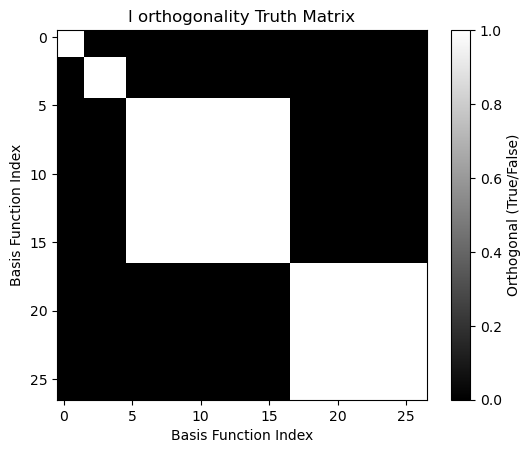

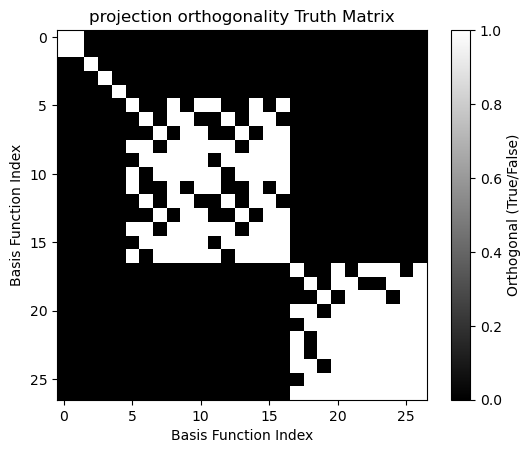

In [24]:
w = ST_contracted(contr_basis, True)

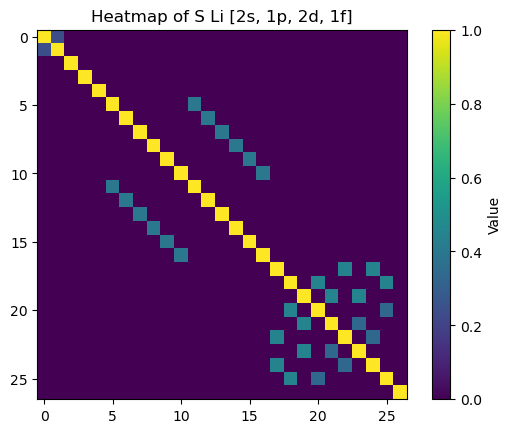

In [25]:
plt.imshow(w[0], cmap='viridis', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Heatmap of S Li [2s, 1p, 2d, 1f]') 
plt.show()

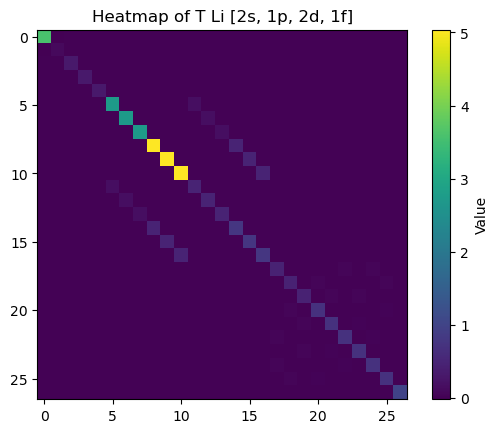

In [26]:
plt.imshow(w[1], cmap='viridis', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Heatmap of T Li [2s, 1p, 2d, 1f]') 
plt.show()

And for the potential:

$$
\mathbf{V}_{\textrm{Li}}^{\textrm{sto-3g}}=
\begin{pmatrix}
-7.9829 & -0.9643& 0 & 0 & 0 \\
-0.9643 & -1.2069 & 0 & 0 & 0 \\
0 & 0 & -1.1973 & 0 & 0 \\
0 & 0 & 0 & -1.1973 & 0 \\
0 & 0 & 0 & 0 & -1.1973
\end{pmatrix}
$$

In [27]:
x = V_contracted(contr_basis, 3, np.array([0., 0., 0.])) # Charge is 3

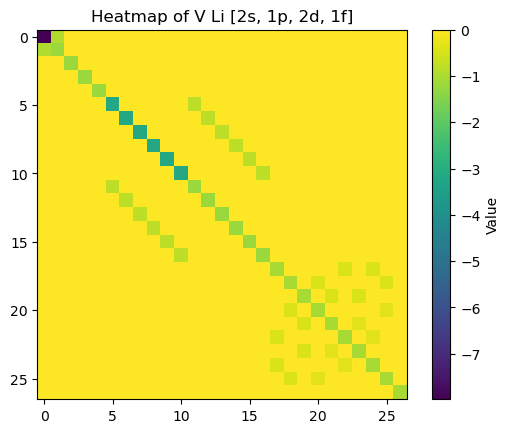

In [28]:
plt.imshow(x, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Heatmap of V Li [2s, 1p, 2d, 1f]') 
plt.show()

Which matches the definition of the STO-3G core Hamiltionian a Li atom.

# Contracted two electron integrals

We are going to apply the same philosopy for now in a naive manner: Build the uncontracted tensor and then contract.

$$
g_{\mu\nu\lambda\sigma} = \sum_p^{p_{max}} \sum_q^{q_{max}}\sum_r^{r_{max}} \sum_s^{s_{max}} c^*_{p \mu} c_{q \nu} c^*_{r \lambda} c_{s \sigma} (pq|rs)
$$

Even though there are some schemes to exploit symmetry or whatever, for now we will calculate naively all matrix elements.

In [29]:
def g_contracted(basis_list_1, basis_list_2, basis_list_3, basis_list_4, cont_coeff_list):
    p_max = len(basis_list_1)
    q_max = len(basis_list_2)
    r_max = len(basis_list_3)
    s_max = len(basis_list_4)

    g_final = 0

    for p in range(p_max):
        for q in range(q_max):
            for r in range(r_max):
                for s in range(s_max):
                    c_pmu = cont_coeff_list[0][p]
                    c_qnu = cont_coeff_list[1][q]
                    c_rlambda = cont_coeff_list[2][r]
                    c_ssigma = cont_coeff_list[3][s]

                    prim_i = basis_list_1[p]
                    prim_j = basis_list_2[q]
                    prim_k = basis_list_3[r]
                    prim_l = basis_list_4[s]

                    g_final += c_pmu * c_qnu * c_rlambda * c_ssigma * g_abcd(prim_i, prim_j, prim_k, prim_l)
    return g_final

In [30]:
def g_contracted(n_primitives: list[int], primitives: list[list[Primitive]], contraction_coefficients: list[list[float]]):

    pass

And in the book it is possible to see that there are 4 unique two electron integrals due to symmetry:

$$
(11|11) = 0.7746 \,a.u
$$
$$
(11|22) = 0.5697 \,a.u
$$
$$
(21|11) = 0.4441 \,a.u
$$
$$
(21|21) = 0.2970 \,a.u
$$

In [31]:
eri_tensor = g_contracted([3,3,3,3], [sto_3g_1s_h1, sto_3g_1s_h1, sto_3g_1s_h1, sto_3g_1s_h1], [c_mu, c_mu, c_mu, c_mu])

In [32]:
eri_tensor